<a href="https://colab.research.google.com/github/mc-ivan/data-science-2026-m2t1gasb/blob/main/week5/notebooks/Class5_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

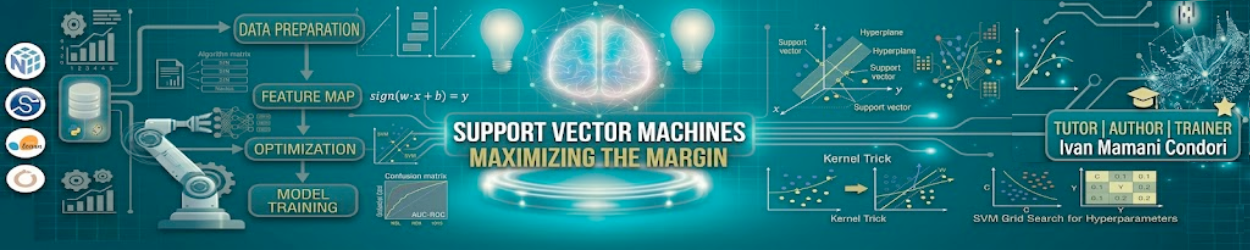

# Binary Classification using SVM – Breast Cancer Coimbra Dataset

**Dataset:** Breast Cancer Coimbra

**Fonte:** UCI Machine Learning Repository

**Link:** https://archive.ics.uci.edu/dataset/451/breast+cancer+coimbra

**Objetivo:**

Desenvolver e avaliar modelos de classificação supervisionada para predizer a presença de ***câncer de mama*** com base em variáveis clínicas e metabólicas de pacientes.

O estudo compara o desempenho de três abordagens:
- Regressão Logística (baseline)
- SVM com kernel linear
- SVM com kernel RBF

A análise considera métricas como:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Com foco especial na capacidade de identificar corretamente casos positivos (câncer), minimizando falsos negativos.

A variável alvo (Classification) foi convertida para formato binário:
- 0 → Paciente saudável
- 1 → Paciente com câncer de mama

**Autor:** Ivan Mamani

---

## 1. Importação de Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

# Branding (Teal)
COLOR_MAIN = "#008080"
COLOR_ACCENT = "#20B2AA"
COLOR_LIGHT = "#E0FFFF"


**Insights**

**❓ Reflexão**
- Por que múltiplas métricas são importantes?

- O que limita o uso apenas de accuracy?

- Por que SVM requer normalização?

## 2. Carregamento do Dataset

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"
df = pd.read_csv(url)  # carrega o CSV como DataFrame
df.head()  # mostra as primeiras linhas

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


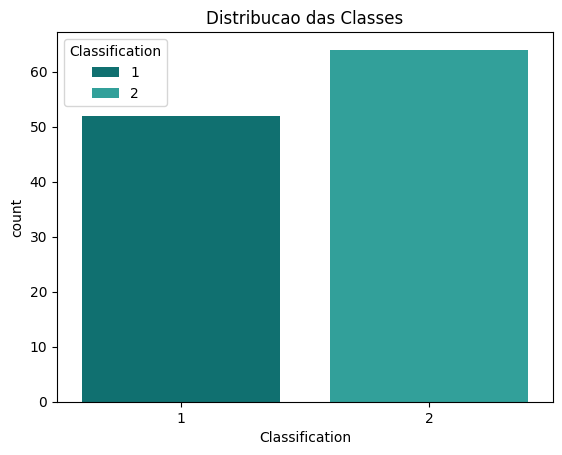

In [ ]:
sns.countplot(x="Classification", data=df, hue="Classification", palette=[COLOR_MAIN, COLOR_ACCENT])
plt.title("Distribucao das Classes")
plt.show()

In [ ]:
df["Classification"] = df["Classification"].map({
    1: 0,
    2: 1
})

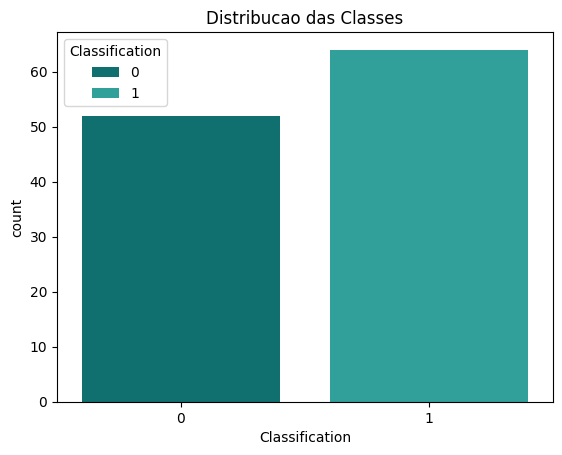

In [ ]:
sns.countplot(x="Classification", data=df, hue="Classification", palette=[COLOR_MAIN, COLOR_ACCENT])
plt.title("Distribucao das Classes")
plt.show()

In [ ]:
df.shape

(116, 10)

**Insights**

**❓ Reflexão**

1. Dataset pequeno afeta overfitting?

2. Por que analisar distribuição das classes?

3. O que indica desbalanceamento?



## 3. Análise Exploratória (EDA)

In [ ]:
# Mostra o número de linhas e colunas do dataset
df.shape

(116, 10)

In [ ]:
# informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB


In [ ]:
# estatísticas
df.describe()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,0.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,0.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,0.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,1.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,1.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,1.000000


In [ ]:
# Conta valores ausentes em cada coluna
df.isnull().sum()

,0
Age,0
BMI,0
Glucose,0
Insulin,0
HOMA,0
Leptin,0
Adiponectin,0
Resistin,0
MCP.1,0
Classification,0


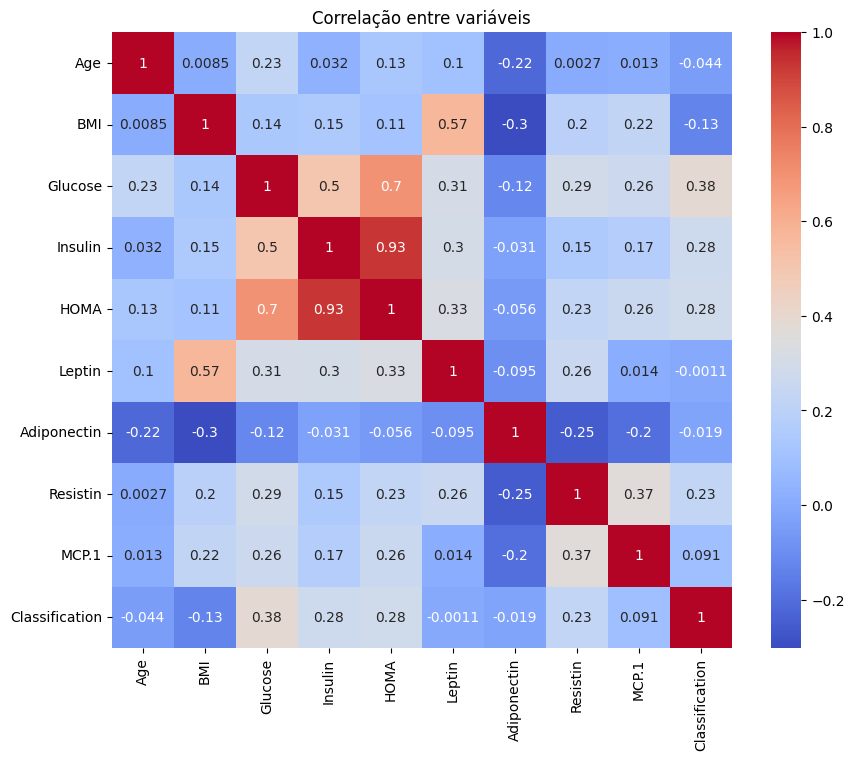

In [ ]:
# Calcula matriz de correlação
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=True) # matriz de correlação
plt.title("Correlação entre variáveis")
plt.show()

In [ ]:
# Ordena variáveis pela correlação com Classification
corr_target = corr["Classification"].sort_values(ascending=False)

corr_target

,Classification
Classification,1.000000
Glucose,0.384315
HOMA,0.284012
Insulin,0.276804
Resistin,0.227310
MCP.1,0.091381
Leptin,-0.001078
Adiponectin,-0.019490
Age,-0.043555
BMI,-0.132586


**Insights**

* Features possuem escalas diferentes.
* Variáveis como insulina, glicose e adiponectina variam bastante.
* Não há valores nulos.

## 4. Preparação dos Dados

In [ ]:
# separa variáveis independentes
X = df.drop("Classification", axis=1)

# variável alvo
y = df["Classification"]

# divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# y_test


**Insights**

* Stratify mantém proporção das classes, garantindo que o modelo veja uma distribuição representativa durante o treinamento.
* A normalização evita que variáveis com maior escala dominem o modelo.
* Este passo é crucial para garantir consistência entre treino e teste.

**❓ Reflexão**

1. Por que aplicar scaler apenas no treino?

2. O que o stratify garante?

## 5. Modelo Baseline: Regressão Logística

In [ ]:
# treinar modelo Logistic Regression (baseline)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# fazer previsões
y_pred_log = log_model.predict(X_test_scaled)
y_pred_log

# calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred_log)

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
custom_map = LinearSegmentedColormap.from_list(
    "teal_brand",
    [COLOR_LIGHT, COLOR_ACCENT, COLOR_MAIN]
)

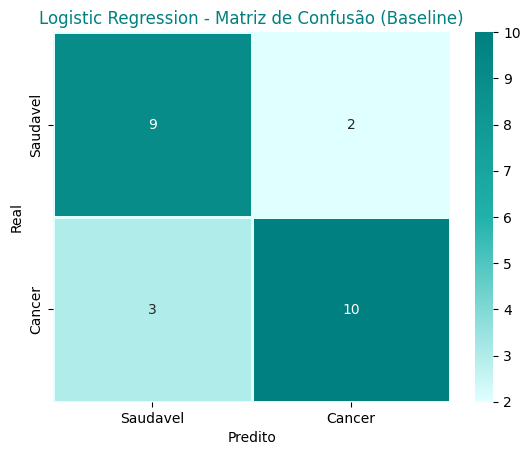

In [ ]:
plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_map,
    cbar=True,
    linewidth=1,
    linecolor=COLOR_LIGHT
)

plt.xticks([0.5, 1.5], ['Saudavel', 'Cancer'])
plt.yticks([0.5, 1.5], ['Saudavel', 'Cancer'])

plt.title("Logistic Regression - Matriz de Confusão (Baseline)", color=COLOR_MAIN)

plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()


**Insights**

* A regressão logística modela a probabilidade de uma instância pertencer a uma classe.
* É altamente interpretável, pois seus coeficientes indicam a influência de cada variável.
* Serve como baseline para entender se modelos mais complexos realmente agregam valor.

**❓ Reflexão**

1. Por que usar um baseline?


2. Quando regressão logística é suficiente?


3. Qual sua limitação?


## 6. SVM Linear

In [ ]:
# treinar modelo SVM linear
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

SVC(kernel='linear')

In [ ]:
# fazer predições
y_pred_linear = svm_linear.predict(X_test_scaled)

# calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred_linear)

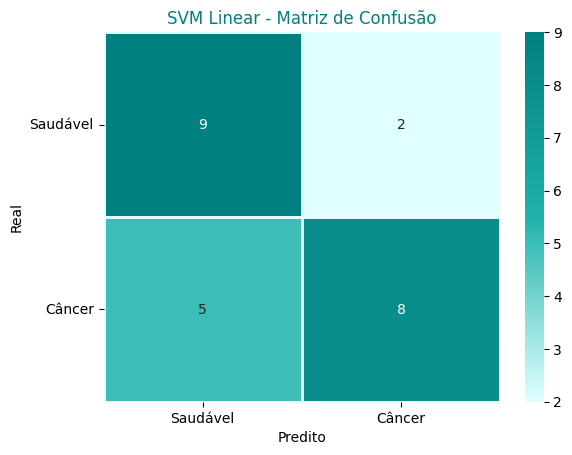

In [ ]:
plt.figure()
sns.heatmap(
    cm,
    annot=True,       # mostrar valores
    fmt='d',          # formato inteiro
    cmap=custom_map, # usar cores do branding
    cbar=True,        # mostrar barra lateral
    linewidths=1,     # linhas entre células
    linecolor=COLOR_LIGHT # cor das linhas
)

# labels mais interpretáveis
plt.xticks([0.5, 1.5], ['Saudável', 'Câncer'])
plt.yticks([0.5, 1.5], ['Saudável', 'Câncer'], rotation=0)

# títulos com branding
plt.title("SVM Linear - Matriz de Confusão", color=COLOR_MAIN)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

**Insights**

* O SVM linear encontra o hiperplano que maximiza a margem entre as classes.
* Isso tende a melhorar a capacidade de generalização do modelo.
* É menos sensível a outliers em comparação com alguns modelos.

**❓ Reflexão**

1. O que é margem em SVM?

2. Por que maximizar a margem?


3. Quando kernel linear funciona bem?



## 7. SVM Kernel RBF

In [ ]:
# treinar modelo SVM RBF
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

SVC()

In [ ]:
# fazer predições
y_pred_rbf = svm_rbf.predict(X_test_scaled)

# calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred_rbf)

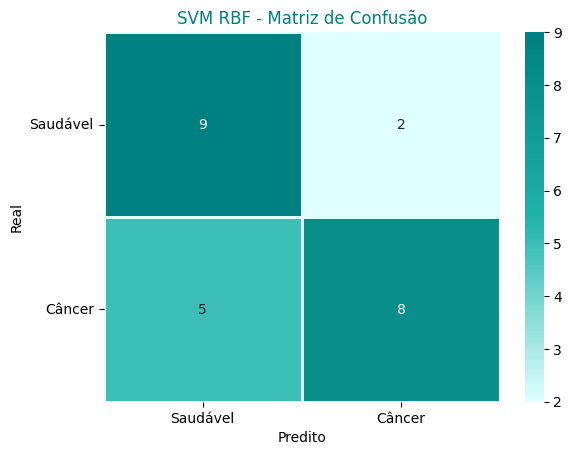

In [ ]:
plt.figure()
sns.heatmap(
    cm,
    annot=True,       # mostrar valores
    fmt='d',          # formato inteiro
    cmap=custom_map, # usar cores do branding
    cbar=True,        # mostrar barra lateral
    linewidths=1,     # linhas entre células
    linecolor=COLOR_LIGHT # cor das linhas
)

# labels mais interpretáveis
plt.xticks([0.5, 1.5], ['Saudável', 'Câncer'])
plt.yticks([0.5, 1.5], ['Saudável', 'Câncer'], rotation=0)

# títulos com branding
plt.title("SVM RBF - Matriz de Confusão", color=COLOR_MAIN)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

**Insights**

* O kernel RBF transforma os dados para um espaço de maior dimensão.
* Permite criar fronteiras de decisão curvas e complexas.
* É mais flexível, mas também mais propenso a overfitting.

**❓ Reflexão**

1. O que o kernel RBF faz?

2. Quando usar RBF?


3. Qual risco?

## 8. Comparação Quantitativa dos Modelos

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM Linear", "SVM RBF"],
    "Accuracy": [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_linear), accuracy_score(y_test, y_pred_rbf)],
    "Precision": [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_linear), precision_score(y_test, y_pred_rbf)],
    "Recall": [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_linear), recall_score(y_test, y_pred_rbf)],
    "F1-score": [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_linear), f1_score(y_test, y_pred_rbf)]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.791667,0.833333,0.769231,0.800000
1,SVM Linear,0.708333,0.800000,0.615385,0.695652
2,SVM RBF,0.708333,0.800000,0.615385,0.695652


In [ ]:
# Otimização do SVM (RBF)
from sklearn.model_selection import GridSearchCV

# definir grade de parâmetros
param_grid = {
    'C': [0.1, 1, 10, 100],        # controle de regularização
    'gamma': [1, 0.1, 0.01, 0.001], # influência dos pontos
    'kernel': ['rbf']              # kernel não linear
}

# criar GridSearch
grid = GridSearchCV(
    SVC(),               # modelo base
    param_grid,          # parâmetros
    refit=True,          # refazer modelo com melhor combinação
    verbose=1            # mostrar progresso
)

# treinar com dados de treino
grid.fit(X_train_scaled, y_train)

# melhor modelo encontrado
best_svm = grid.best_estimator_

# melhores parâmetros
print("Melhores parâmetros:", grid.best_params_)

# predição com modelo otimizado
y_pred_rbf_tuned = best_svm.predict(X_test_scaled)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Melhores parâmetros: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM Linear",
        "SVM RBF",
        "SVM RBF Tuned"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_rbf_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_rbf),
        precision_score(y_test, y_pred_rbf_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_linear),
        recall_score(y_test, y_pred_rbf),
        recall_score(y_test, y_pred_rbf_tuned)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_rbf),
        f1_score(y_test, y_pred_rbf_tuned)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.791667,0.833333,0.769231,0.800000
1,SVM Linear,0.708333,0.800000,0.615385,0.695652
2,SVM RBF,0.708333,0.800000,0.615385,0.695652
3,SVM RBF Tuned,0.750000,0.818182,0.692308,0.750000


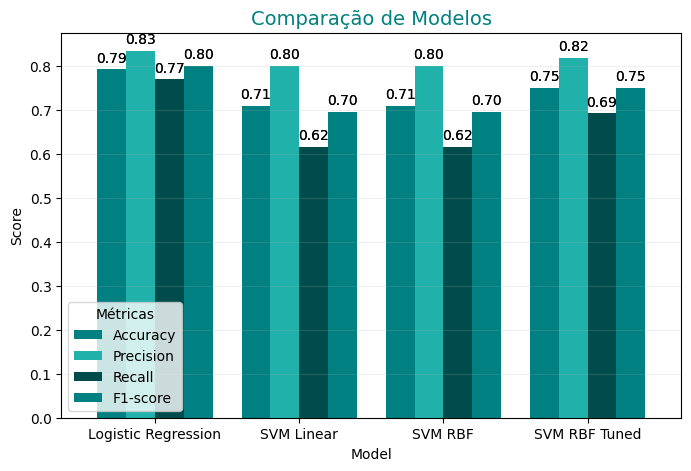

In [ ]:
ax = results.set_index('Model').plot(
    kind='bar',           # tipo de gráfico
    figsize=(8,5),        # tamanho
    width=0.8,            # largura das barras
    color=[COLOR_MAIN, COLOR_ACCENT, "#004C4C"]
)

colors = [COLOR_MAIN, COLOR_ACCENT, "#004C4C"]

# adicionar valores
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Comparação de Modelos", color=COLOR_MAIN, fontsize=14)

# rótulo eixo Y
plt.ylabel("Score")

# melhorar rotação dos labels
plt.xticks(rotation=0)

# grid leve para melhor leitura
plt.grid(axis='y', alpha=0.2)

# legenda estilizada
plt.legend(title="Métricas")

# adicionar valores em cima das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

**Interpretação da Comparação**

* **Accuracy:** mede o desempenho geral, mas pode mascarar erros importantes.
* **Precision:** indica quantos dos positivos previstos realmente são positivos.
* **Recall:** mede quantos casos reais de câncer foram corretamente identificados.
* **F1-score:** equilibra precision e recall, sendo útil em datasets desbalanceados.

Em problemas médicos:

* Recall é crítico porque falsos negativos podem significar pacientes doentes não diagnosticados.
* Precision também é importante para evitar diagnósticos incorretos.

**❓ Reflexão**

1. Por que recall é mais importante que accuracy?

2. Quando precision é importante?

3. Por que usar F1-score?

## 9. Curva ROC e AUC

In [ ]:
# PROBABILIDADES / SCORES
# probabilidades do modelo Logistic Regression
log_probs = log_model.predict_proba(X_test_scaled)[:,1]

# scores do SVM Linear (distância ao hiperplano)
svm_linear_scores = svm_linear.decision_function(X_test_scaled)

# scores do SVM RBF
svm_rbf_scores = svm_rbf.decision_function(X_test_scaled)

# scores do SVM RBF otimizado (tuned)
svm_rbf_tuned_scores = best_svm.decision_function(X_test_scaled)

# CURVAS ROC
# calcular FPR e TPR para cada
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_lin, tpr_lin, _ = roc_curve(y_test, svm_linear_scores)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, svm_rbf_scores)
fpr_rbf_tuned, tpr_rbf_tuned, _ = roc_curve(y_test, svm_rbf_tuned_scores)

# CÁLCULO DO AUC
auc_log = auc(fpr_log, tpr_log)  # AUC Logistic
auc_lin = auc(fpr_lin, tpr_lin)  # AUC SVM Linear
auc_rbf = auc(fpr_rbf, tpr_rbf)  # AUC SVM RBF
auc_rbf_tuned = auc(fpr_rbf_tuned, tpr_rbf_tuned)  # AUC SVM Tuned

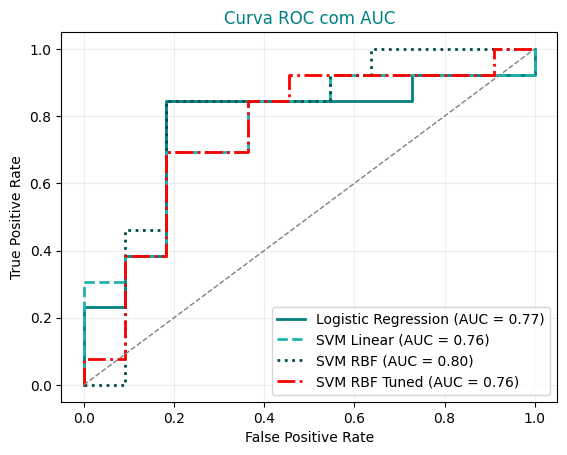

In [ ]:
plt.figure()
# Logistic Regression
plt.plot(
    fpr_log, tpr_log,
    color=COLOR_MAIN,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_log:.2f})"
)

# SVM Linear
plt.plot(
    fpr_lin, tpr_lin,
    color=COLOR_ACCENT,
    linestyle='--',
    linewidth=2,
    label=f"SVM Linear (AUC = {auc_lin:.2f})"
)

# SVM RBF
plt.plot(
    fpr_rbf, tpr_rbf,
    color="#004C4C",  # tom mais escuro do teal
    linestyle=':',
    linewidth=2,
    label=f"SVM RBF (AUC = {auc_rbf:.2f})"
)

# SVM rbf_tuned
plt.plot(
    fpr_rbf_tuned, tpr_rbf_tuned,
    color="red",  # variação intermediária do teal
    linestyle='-.',
    linewidth=2,
    label=f"SVM RBF Tuned (AUC = {auc_rbf_tuned:.2f})"
)
plt.plot([0,1], [0,1], color="gray", linestyle='--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Curva ROC com AUC", color=COLOR_MAIN)
plt.legend(loc="lower right")

plt.grid(alpha=0.2)

plt.show()

**Insights**

* A curva ROC mostra o trade-off entre sensibilidade e especificidade.
* AUC mais alto indica melhor separação entre classes.
* Modelos com maior AUC são preferíveis.


## 10. Discussão Comparativa

**Comparação Geral**


**Interpretação Clínica**


**Trade-offs**


## 11. Conclusão


**❓ Reflexões Finais**

1. Qual modelo é mais adequado para produção?


2. Por que o recall é mais importante que accuracy?


3. Quando usar kernel RBF?


## 12. PCA para graficar melhor o comportamento dos dados

In [ ]:
# 1. PCA (ajustado SOLO en treino)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

# ajustar PCA apenas nos dados de treino (evita data leakage)
X_train_pca = pca.fit_transform(X_train_scaled)

# aplicar transformação no teste
X_test_pca = pca.transform(X_test_scaled)


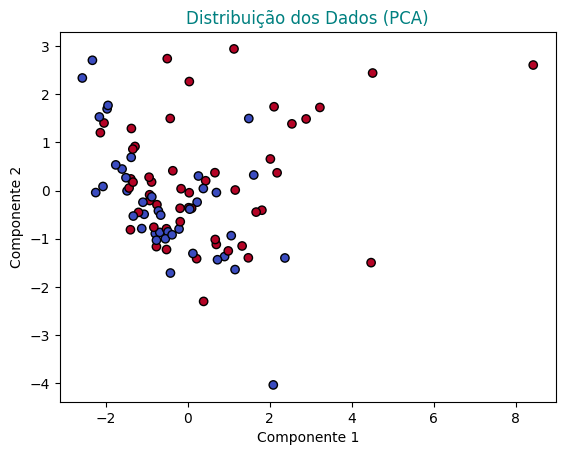

In [ ]:
# 2. VISUALIZAÇÃO DOS DADOS
plt.figure()

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap='coolwarm',
    edgecolors='k'
)

plt.title("Distribuição dos Dados (PCA)", color=COLOR_MAIN)
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.show()

In [ ]:
# 3. MODELOS
# Logistic Regression (baseline)
log_pca = LogisticRegression()
log_pca.fit(X_train_pca, y_train)

# SVM Linear
svm_linear_pca = SVC(kernel='linear')
svm_linear_pca.fit(X_train_pca, y_train)

# SVM RBF
svm_rbf_pca = SVC(kernel='rbf')
svm_rbf_pca.fit(X_train_pca, y_train)

SVC()

In [ ]:
# 4. SVM RBF OTIMIZADO (TUNED)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid_pca = GridSearchCV(SVC(), param_grid, refit=True, verbose=0)

# treinar com dados PCA
grid_pca.fit(X_train_pca, y_train)

# melhor modelo
best_svm_pca = grid_pca.best_estimator_

best_svm_pca

SVC(C=100, gamma=0.01)

In [ ]:
# 5. GRID PARA FRONTEIRA DE DECISÃO
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

In [ ]:
# 6. PREVISÕES
Z_log = log_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_log = Z_log.reshape(xx.shape)

Z_linear = svm_linear_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z_linear.reshape(xx.shape)

Z_rbf = svm_rbf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

# modelo tuned
Z_rbf_tuned = best_svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf_tuned = Z_rbf_tuned.reshape(xx.shape)


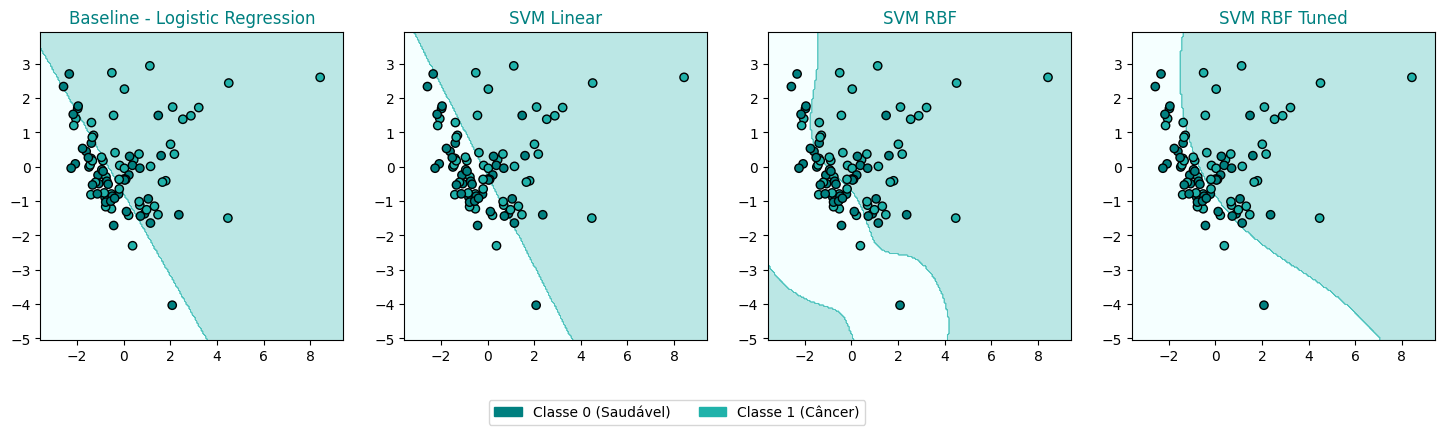

In [ ]:
# 7. PLOT COM BRANDING
from matplotlib.colors import ListedColormap

cmap_bg = ListedColormap([COLOR_LIGHT, COLOR_ACCENT])
cmap_points = ListedColormap([COLOR_MAIN, COLOR_ACCENT])

plt.figure(figsize=(18,4))


# SUBPLOT 1: Logistic
plt.subplot(1,4,1)
plt.contourf(xx, yy, Z_log, alpha=0.3, cmap=cmap_bg)
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap=cmap_points, edgecolors='k')
plt.title("Baseline - Logistic Regression", color=COLOR_MAIN)

# SUBPLOT 2: SVM Linear
plt.subplot(1,4,2)
plt.contourf(xx, yy, Z_linear, alpha=0.3, cmap=cmap_bg)
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap=cmap_points, edgecolors='k')
plt.title("SVM Linear", color=COLOR_MAIN)

# SUBPLOT 3: SVM
plt.subplot(1,4,3)
plt.contourf(xx, yy, Z_rbf, alpha=0.3, cmap=cmap_bg)
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap=cmap_points, edgecolors='k')
plt.title("SVM RBF", color=COLOR_MAIN)

# SUBPLOT 4: SVM RBF Tuned
plt.subplot(1,4,4)
plt.contourf(xx, yy, Z_rbf_tuned, alpha=0.3, cmap=cmap_bg)
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap=cmap_points, edgecolors='k')
plt.title("SVM RBF Tuned", color=COLOR_MAIN)

# LEGENDA
import matplotlib.patches as mpatches

legend_labels = [
    mpatches.Patch(color=COLOR_MAIN, label='Classe 0 (Saudável)'),
    mpatches.Patch(color=COLOR_ACCENT, label='Classe 1 (Câncer)')
]

plt.legend(handles=legend_labels, loc='lower center', bbox_to_anchor=(-1.5, -0.3), ncol=2)

plt.show()


In [ ]:
# ver componentes principais
components = pd.DataFrame(
    pca.components_,  # coeficientes
    columns=X.columns,  # nomes das features
    index=['PC1', 'PC2']  # nomes dos componentes
)

components

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1
PC1,0.077499,0.299099,0.432266,0.457542,0.503212,0.313591,-0.192088,0.208938,0.276079
PC2,-0.155557,-0.405644,0.144991,0.390082,0.374409,-0.164162,0.474002,-0.444892,-0.219839
